# 03. Multisensor fusion

One request can bring together everything the library reads. This notebook fuses, over Berlin in August 2026:

| Source | What it adds | Grid |
|---|---|---|
| Sentinel-3 SLSTR | land surface temperature, the fusion target | 1 km |
| Sentinel-2 MSI | reflectance and spectral indices (NDVI, NDBI, EVI, NDMI, MNDWI) | 100 m |
| Sentinel-1 SAR (Planetary Computer RTC) | radar backscatter, which sees through clouds | 100 m |
| Sentinel-5P TROPOMI | tropospheric nitrogen dioxide column | 100 m (from 0.01 degree) |
| Landsat 8/9 | independent 100 m land surface temperature | 100 m |
| ECOSTRESS | independent 70 m land surface temperature at varying times of day | 100 m |
| ERA5 | 2 m air temperature and boundary layer height | 0.25 degree |
| CAMS | modelled atmospheric nitrogen dioxide | 0.4 degree |
| OpenAQ | ground-station nitrogen dioxide | points, interpolated to 100 m |
| Copernicus GLO-30 | elevation, slope, aspect, solar illumination | 100 m |

The result has two main cubes: the **fused cube** on the 1 km thermal grid, with every other source aggregated onto it and matched in time to each Sentinel-3 scene, and , one 100 m cube per sensor, each on that sensor's own acquisition times. Then we look at each source and at how they relate.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
def extent_km(da):
    """imshow extent of a projected y/x grid, in kilometres."""
    x, y = da["x"].values, da["y"].values
    dx, dy = abs(x[1] - x[0]), abs(y[1] - y[0])
    return [(x.min() - dx / 2) / 1e3, (x.max() + dx / 2) / 1e3, (y.min() - dy / 2) / 1e3, (y.max() + dy / 2) / 1e3]


def show_map(ax, da, title, cmap="inferno", label=None, vmin=None, vmax=None):
    """One georeferenced map with a colour bar; axes in UTM kilometres."""
    image = ax.imshow(da.values, extent=extent_km(da), cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("easting (km)")
    ax.set_ylabel("northing (km)")
    plt.colorbar(image, ax=ax, shrink=0.8, label=label or da.attrs.get("units", ""))
    return image

In [3]:
import dataclasses
import logging
import time

import citycube as cc

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
for noisy in ("httpx", "rasterio", "urllib3", "cdsapi", "ecmwf", "datapi", "openeo"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

## 1. The request

* `sentinel1_backend="pc_rtc"` reads terrain-corrected backscatter from Planetary Computer, with no SNAP installation; `sentinel2_source="stac_cog"` reads Sentinel-2 in place.
* `temporal_tolerances` sets how far in time each source may be from a Sentinel-3 scene to be matched with it; one day for the sensors that pass daily or nearly so.
* The CAMS reanalysis is published months late, so for August 2026 the CAMS *forecast* dataset is used.
* OpenAQ stations are interpolated onto the predictor grid with guarded inverse-distance weighting (it refuses to extrapolate far from stations).

In [4]:
berlin = cc.get_city("berlin")
request = cc.AnalysisRequest.for_city(
    berlin, "2026-08-01", "2026-08-21",
    sensors=("sentinel3", "sentinel2", "sentinel1", "sentinel5p", "landsat", "ecostress"),
    variables=("lst", "NO2"),
    resolution_m=100,
    max_products_per_sensor=12,
    auxiliary=(
        # ERA5-Land has no boundary layer height; the single-levels reanalysis (0.25 degree) has both.
        cc.AuxiliarySpec("era5", variables=("air_temperature_2m", "boundary_layer_height"), dataset="reanalysis-era5-single-levels"),
        cc.AuxiliarySpec("cams", variables=("NO2",), dataset="cams-global-atmospheric-composition-forecasts"),
        cc.AuxiliarySpec("openaq", variables=("NO2",), options={"max_locations": 20}),
    ),
)
request = dataclasses.replace(
    request,
    sentinel2_source="stac_cog",
    sentinel1_backend="pc_rtc",
    s2_cloud_cover_max=60,
    thermal_overpass="day",
    terrain_predictors=True,
    temporal_tolerances={name: np.timedelta64(1, "D") for name in ("sentinel1", "sentinel5p", "landsat", "ecostress")},
)
print(cc.estimate_request(request).to_dict())

started = time.time()
result = cc.AnalysisWorkflow(request).execute(WORK)
print(f"done in {(time.time() - started) / 60:.1f} min")
cube, predictors = result.cube, result.predictors  # predictors: one 100 m cube per sensor

{'aoi_km2': 474.3, 'cells': {'sentinel3': 550, 'sentinel2': 50058, 'sentinel1': 50058, 'sentinel5p': 648, 'landsat': 50058, 'ecostress': 50058}, 'estimated_gb': 0.151}


INFO citycube.workflow.runner: sentinel3: 40 candidate products, 37 cover at least 30% of the AOI, 12 selected


INFO citycube.workflow.runner: sentinel2: 19 candidate products, 17 cover at least 30% of the AOI, 12 selected


INFO citycube.workflow.runner: sentinel1: 16 candidate products, 16 cover at least 30% of the AOI, 12 selected


INFO citycube.workflow.runner: sentinel5p: 37 candidate products, 35 cover at least 30% of the AOI, 12 selected


...

INFO citycube.workflow.runner: landsat: prepared 6 acquisitions


INFO citycube.workflow.runner: ecostress: acquiring 12 products


INFO citycube.workflow.runner: ecostress: prepared 6 acquisitions


INFO citycube.workflow.runner: Fused cube: 12 times, 66 variables


done in 14.3 min


## 2. What came back

`provenance` records which sources contributed, any product that failed and was skipped, and the software version.

In [5]:
{key: value for key, value in result.provenance.items() if key != "variables"}

{'software': {'version': '0.2.0',
  'git_commit': '968972301370ce20ae71c997af3234de46790b1a',
  'git_dirty': True},
 'sensors': ['sentinel3',
  'sentinel2',
  'sentinel1',
  'sentinel5p',
  'landsat',
  'ecostress'],
 'auxiliary': ['era5', 'cams', 'openaq'],
 'auxiliary_rasters': ['openaq'],
 'target_sensor': 'sentinel3',
 'failed_products': [],
 'probed_out': []}

In [6]:
def source_of(name, var):
    """Every variable records the sensor or provider it came from in its attributes."""
    for prefix in ("auxiliary_era5", "auxiliary_cams", "auxiliary_openaq"):
        if name.startswith(prefix):
            return prefix.removeprefix("auxiliary_")
    for prefix in ("sentinel2", "sentinel1", "sentinel5p", "landsat", "ecostress"):
        if name.startswith(prefix):
            return prefix
    return str(var.attrs.get("sensor") or ("terrain" if name in ("elevation", "slope", "aspect", "cos_incidence") else "fusion diagnostics"))


inventory = pd.DataFrame([
    {"cube": label, "variable": name, "source": source_of(name, var), "units": var.attrs.get("units", ""), "finite": float(np.isfinite(var.values).mean()) if var.dtype.kind == "f" else None}
    for label, dataset in (("fused 1 km", cube), *((f"{sensor} 100 m", data) for sensor, data in predictors.items()))
    for name, var in dataset.data_vars.items()
])
print("fused:", dict(cube.sizes))
for sensor, data in predictors.items():
    print(f"{sensor}: {dict(data.sizes)}")
inventory.groupby(["cube", "source"]).variable.apply(lambda names: ", ".join(names[:8]) + (" ..." if len(names) > 8 else ""))

fused: {'time': 12, 'y': 22, 'x': 25}
sentinel2: {'time': 4, 'y': 206, 'x': 243}
sentinel1: {'time': 12, 'y': 206, 'x': 243}
sentinel5p: {'time': 8, 'y': 206, 'x': 243}
landsat: {'time': 6, 'y': 206, 'x': 243}
ecostress: {'time': 6, 'y': 206, 'x': 243}


cube              source            
ecostress 100 m   ecostress                                                                     ecostress_lst
                  fusion diagnostics                                                               valid_mask
fused 1 km        Sentinel-1                            gamma0_VV, gamma0_VH, VH_VV_ratio_dB, RVI, radar_span
                  Sentinel-2                                      B02, B03, B04, B08, B11, B12, SCL, NDVI ...
                  Sentinel-3            lst, lst_uncertainty, sat_zenith, cloud_mask, exception_flags, clo...
                  Sentinel-5P                                                                             NO2
                  cams                  auxiliary_cams_NO2, auxiliary_cams_matched_time, auxiliary_cams_ti...
                  ecostress             ecostress_lst, ecostress_valid_mask, ecostress_matched_time, ecost...
                  era5                  auxiliary_era5_air_temperature_2m, auxiliar

## 3. Matching in time

For every Sentinel-3 scene, each source contributes its nearest acquisition within the tolerance. `<sensor>_time_delta` records how far apart they were, and `NaT` means nothing was close enough. Sentinel-1 sees through clouds, so it nearly always matches; optical sensors match only on clear days.

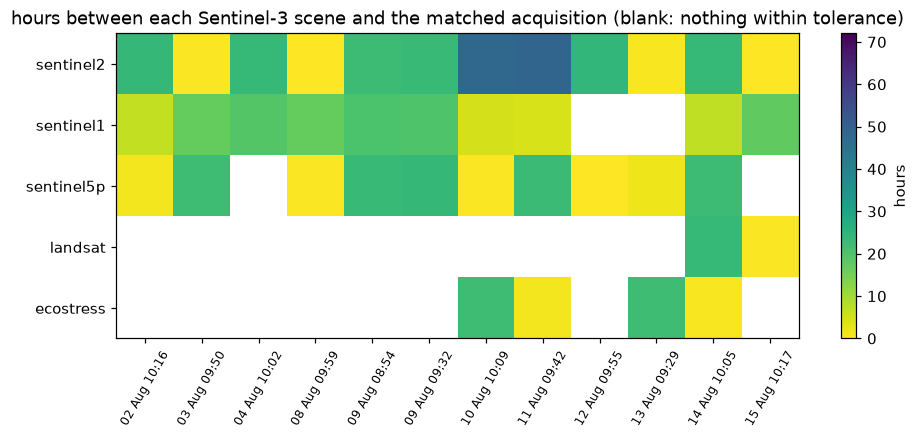

In [7]:
deltas = pd.DataFrame({
    sensor: (cube[f"{sensor}_time_delta"].values / np.timedelta64(1, "h"))
    for sensor in ("sentinel2", "sentinel1", "sentinel5p", "landsat", "ecostress")
    if f"{sensor}_time_delta" in cube
}, index=pd.DatetimeIndex(cube.time.values).strftime("%d %b %H:%M"))

tolerance_hours = max(request.tolerance_for(sensor) / np.timedelta64(1, "h") for sensor in deltas.columns)
fig, ax = plt.subplots(figsize=(10, 3.6))
image = ax.imshow(deltas.T.values, aspect="auto", cmap="viridis_r", vmin=0, vmax=tolerance_hours)
ax.set_yticks(range(deltas.shape[1]), deltas.columns)
ax.set_xticks(range(len(deltas)), deltas.index, rotation=60, fontsize=8)
ax.set_title("hours between each Sentinel-3 scene and the matched acquisition (blank: nothing within tolerance)")
plt.colorbar(image, ax=ax, label="hours")
fig.savefig(FIGURES / "03_time_matching.png", bbox_inches="tight")
plt.show()

## 4. Each source

### Sentinel-2: reflectance and indices

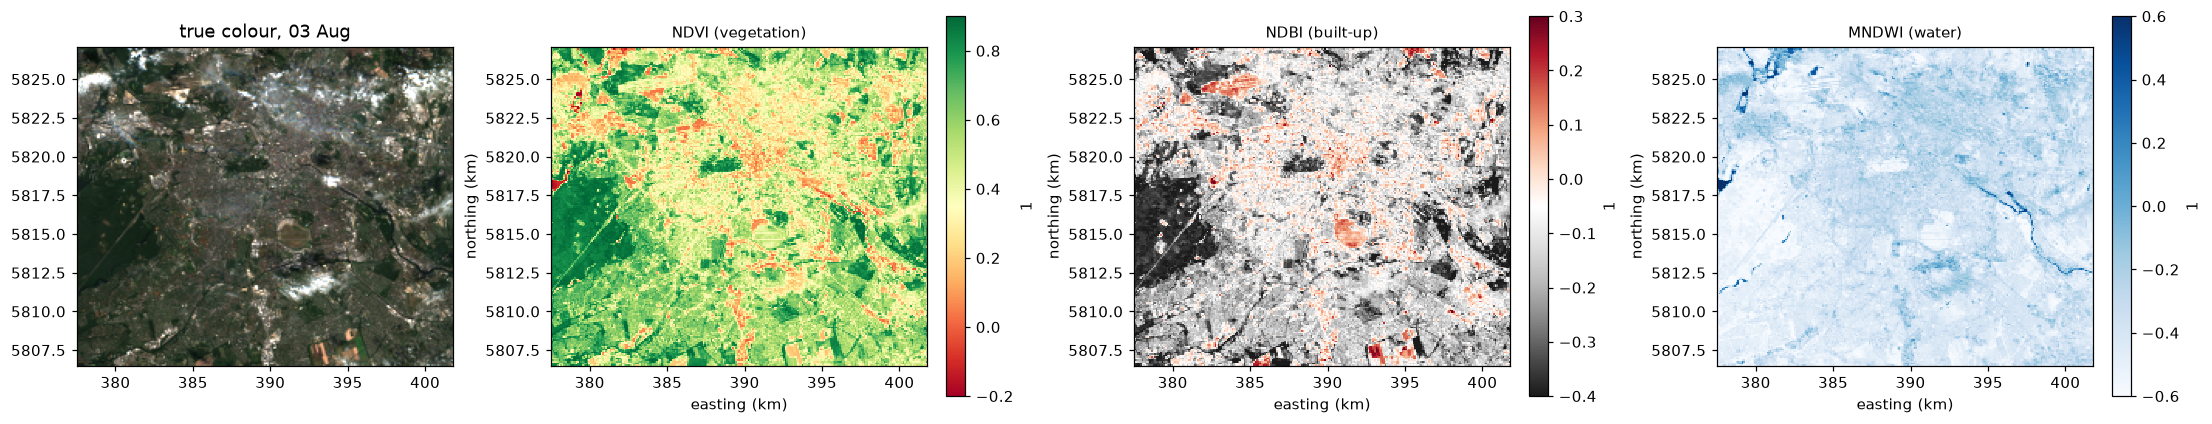

In [8]:
s2_cube = predictors["sentinel2"]
s2_times = [t for t in s2_cube.time.values if s2_cube["NDVI"].sel(time=t).notnull().mean() > 0.6]
s2 = s2_cube.sel(time=s2_times[0])
stack = np.dstack([s2[band].values for band in ("B04", "B03", "B02")])

fig, axes = plt.subplots(1, 4, figsize=(20, 4.4), constrained_layout=True)
axes[0].imshow(np.clip(stack / 0.25, 0, 1), extent=extent_km(s2["NDVI"]))
axes[0].set_title(f"true colour, {pd.Timestamp(s2.time.values):%d %b}")
show_map(axes[1], s2["NDVI"], "NDVI (vegetation)", cmap="RdYlGn", label="", vmin=-0.2, vmax=0.9)
show_map(axes[2], s2["NDBI"], "NDBI (built-up)", cmap="RdGy_r", label="", vmin=-0.4, vmax=0.3)
show_map(axes[3], s2["MNDWI"], "MNDWI (water)", cmap="Blues", label="", vmin=-0.6, vmax=0.6)
fig.savefig(FIGURES / "03_sentinel2.png", bbox_inches="tight")
plt.show()

### Sentinel-1: radar backscatter

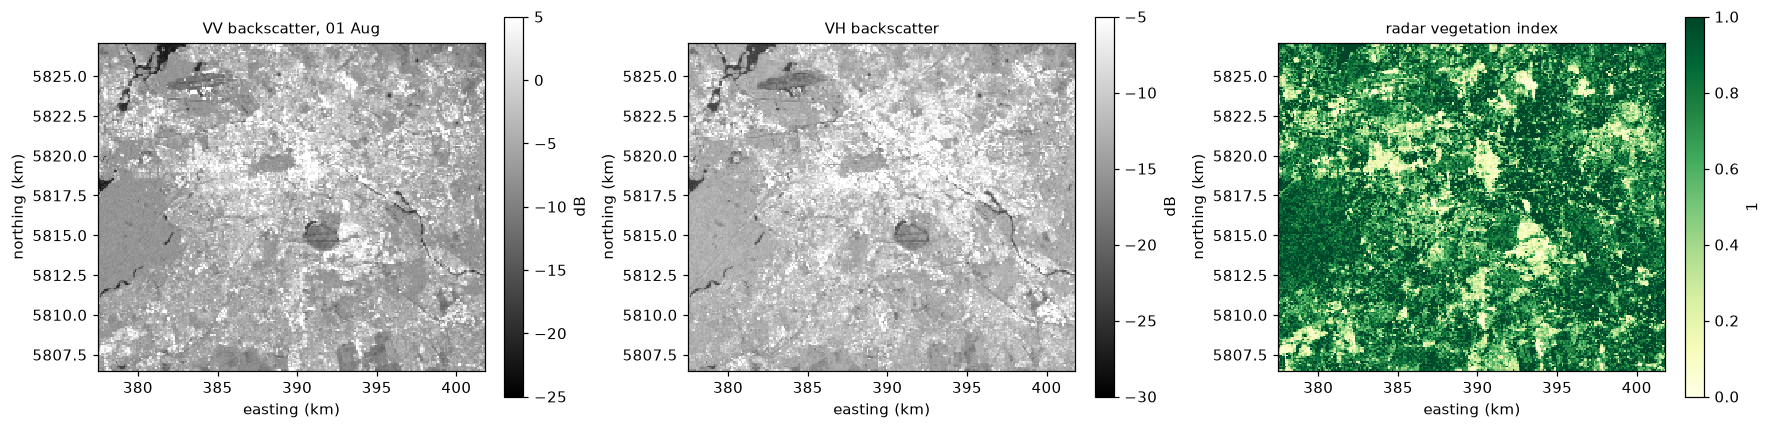

In [9]:
s1_cube = predictors["sentinel1"]
s1_name_vv = next(name for name in s1_cube.data_vars if name.endswith("_VV") and name.startswith(("gamma0", "sigma0")))
s1_times = [t for t in s1_cube.time.values if s1_cube[s1_name_vv].sel(time=t).notnull().mean() > 0.6]
s1 = s1_cube.sel(time=s1_times[0])
to_db = lambda da: 10 * np.log10(da.where(da > 0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
show_map(axes[0], to_db(s1[s1_name_vv]), f"VV backscatter, {pd.Timestamp(s1.time.values):%d %b}", cmap="gray", label="dB", vmin=-25, vmax=5)
show_map(axes[1], to_db(s1[s1_name_vv.replace("_VV", "_VH")]), "VH backscatter", cmap="gray", label="dB", vmin=-30, vmax=-5)
show_map(axes[2], s1["RVI"], "radar vegetation index", cmap="YlGn", label="", vmin=0, vmax=1)
fig.savefig(FIGURES / "03_sentinel1.png", bbox_inches="tight")
plt.show()

Bright VV returns are buildings (double bounce off walls and streets); dark areas are water and smooth surfaces such as the Tempelhof airfield's runways.

### Thermal: Sentinel-3, Landsat and ECOSTRESS

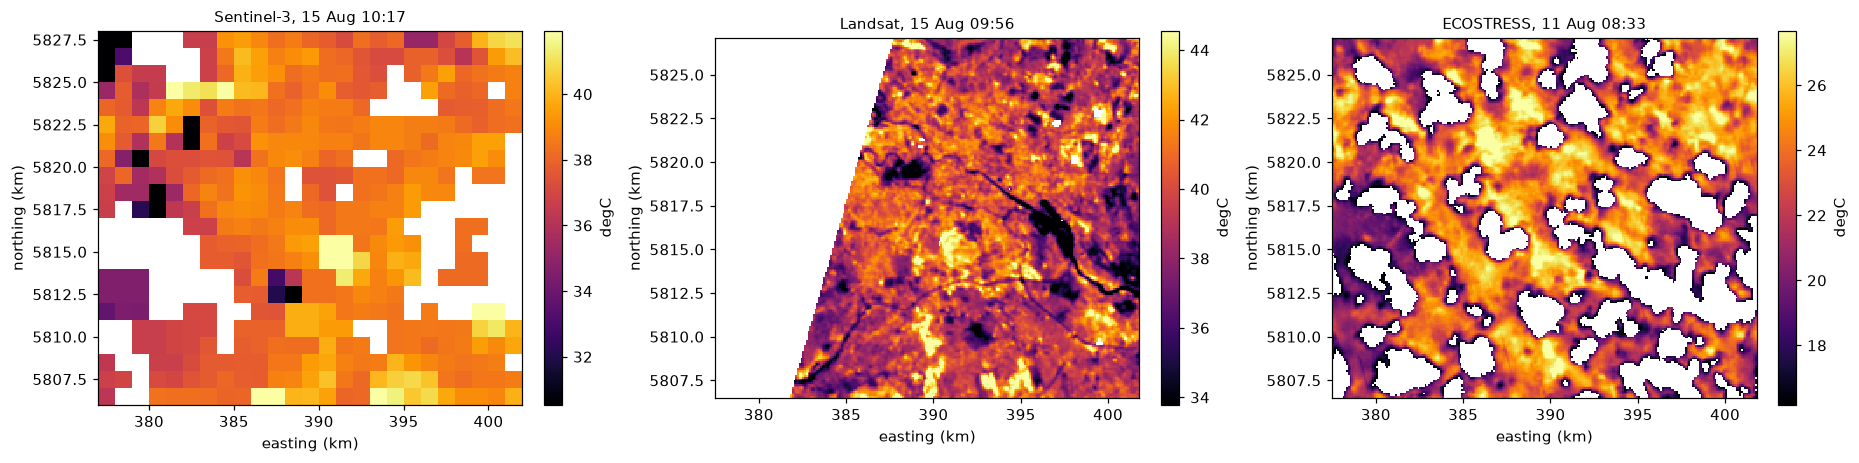

In [10]:
landsat, ecostress = predictors["landsat"], predictors.get("ecostress")
landsat_times = [t for t in landsat.time.values if landsat["landsat_lst"].sel(time=t).notnull().mean() > 0.5]
eco_times = [t for t in ecostress.time.values if ecostress["ecostress_lst"].sel(time=t).notnull().mean() > 0.3] if ecostress is not None else []
t_landsat = landsat_times[0]
t_s3 = cube.time.values[np.argmin(np.abs(cube.time.values - t_landsat))]

panels = [(cube["lst"].sel(time=t_s3), f"Sentinel-3, {pd.Timestamp(t_s3):%d %b %H:%M}"),
          (landsat["landsat_lst"].sel(time=t_landsat), f"Landsat, {pd.Timestamp(t_landsat):%d %b %H:%M}")]
if eco_times:
    panels.append((ecostress["ecostress_lst"].sel(time=eco_times[0]), f"ECOSTRESS, {pd.Timestamp(eco_times[0]):%d %b %H:%M}"))
fig, axes = plt.subplots(1, len(panels), figsize=(5.6 * len(panels), 4.4), constrained_layout=True)
for ax, (data, title) in zip(np.atleast_1d(axes), panels):
    low, high = np.nanpercentile(data.values, [2, 98])  # each its own scale: different days and times of day
    show_map(ax, data, title, label="degC", vmin=low, vmax=high)
fig.savefig(FIGURES / "03_thermal_sensors.png", bbox_inches="tight")
plt.show()

Landsat aggregated to 1 km is already in the fused cube (`landsat_lst`), so the two sensors can be compared cell by cell. They measure the same quantity minutes apart, but with different instruments and emissivity assumptions.

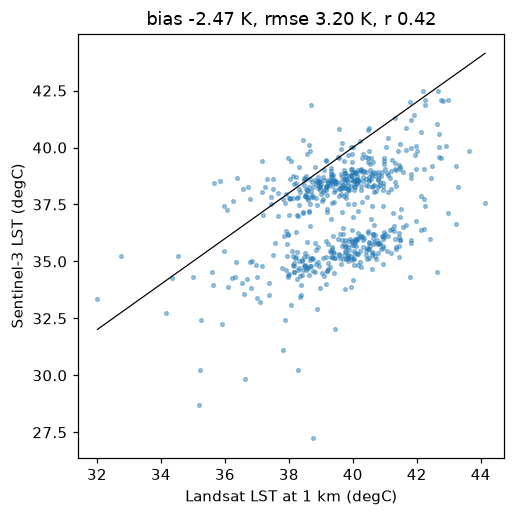

In [11]:
pairs = cube[["lst", "landsat_lst"]].where(cube["landsat_time_delta"].notnull(), drop=True) if "landsat_time_delta" in cube else None
if pairs is not None and pairs.sizes.get("time", 0):
    metrics = cc.validate_independent_reference(pairs["lst"], pairs["landsat_lst"], reference_name="landsat")
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(pairs["landsat_lst"].values.ravel(), pairs["lst"].values.ravel(), s=6, alpha=0.4)
    lims = [np.nanmin(pairs["landsat_lst"]), np.nanmax(pairs["landsat_lst"])]
    ax.plot(lims, lims, color="black", lw=0.8)
    ax.set_xlabel("Landsat LST at 1 km (degC)")
    ax.set_ylabel("Sentinel-3 LST (degC)")
    ax.set_title(f"bias {metrics['bias']:+.2f} K, rmse {metrics['rmse']:.2f} K, r {metrics['correlation']:.2f}")
    plt.show()

### Air quality: Sentinel-5P, CAMS and ground stations

TROPOMI measures nitrogen dioxide once a day around 13:30 local time when the sky is clear enough. Each of its pixels covers about 5.5 x 3.5 km, so `grid_s5p` spreads every valid pixel over the cells inside its footprint. OpenAQ stations are interpolated by guarded inverse-distance weighting and are left blank far from any station.

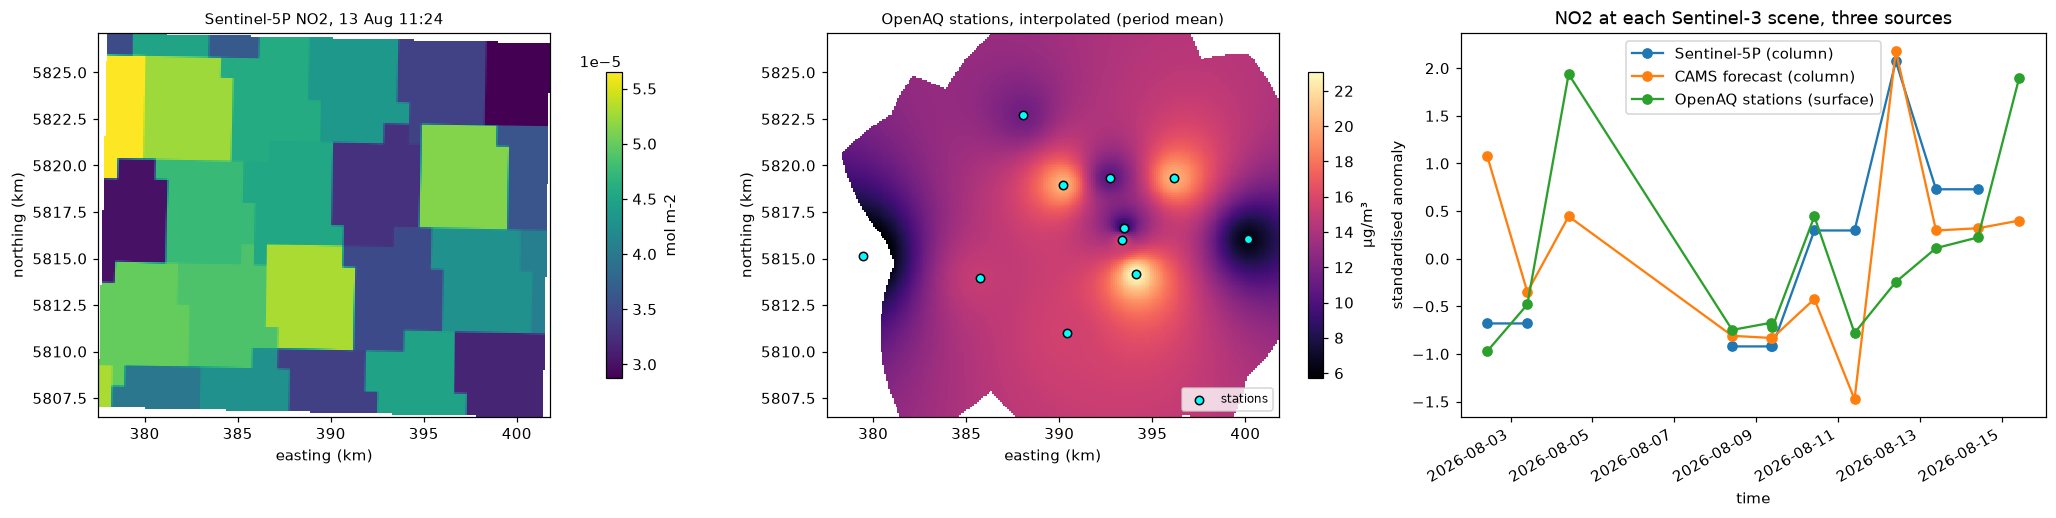

In [12]:
no2_columns = cube["NO2"]  # Sentinel-5P tropospheric column, on the 1 km grid
cams_name = "auxiliary_cams_NO2" if "auxiliary_cams_NO2" in cube else None
openaq = (result.auxiliary or {}).get("openaq")
openaq_grid = (result.auxiliary or {}).get("openaq_grid")

fig, axes = plt.subplots(1, 3, figsize=(19, 4.6), constrained_layout=True)
s5p_no2 = predictors["sentinel5p"]["NO2"]
s5p_best = s5p_no2.isel(time=int(s5p_no2.notnull().mean(["y", "x"]).argmax()))
show_map(axes[0], s5p_best, f"Sentinel-5P NO2, {pd.Timestamp(s5p_best.time.values):%d %b %H:%M}", cmap="viridis", label="mol m-2")
if openaq_grid is not None:
    surface = openaq_grid["NO2"].mean("time")
    show_map(axes[1], surface, "OpenAQ stations, interpolated (period mean)", cmap="magma", label=openaq_grid["NO2"].attrs.get("units", ""))
    from pyproj import Transformer
    sx, sy = Transformer.from_crs("EPSG:4326", cube.attrs["crs"], always_xy=True).transform(openaq["longitude"].values, openaq["latitude"].values)
    axes[1].scatter(np.asarray(sx) / 1e3, np.asarray(sy) / 1e3, c="cyan", edgecolor="black", s=30, label="stations")
    axes[1].legend(loc="lower right", fontsize=8)
series = pd.DataFrame({"Sentinel-5P (column)": no2_columns.mean(["y", "x"]).to_series()})
if cams_name:
    series["CAMS forecast (column)"] = cube[cams_name].mean(["y", "x"]).to_series()
if "auxiliary_openaq_NO2" in cube:
    series["OpenAQ stations (surface)"] = cube["auxiliary_openaq_NO2"].mean(["y", "x"]).to_series()
standardised = (series - series.mean()) / series.std()
standardised.plot(ax=axes[2], marker="o")
axes[2].set_ylabel("standardised anomaly")
axes[2].set_title("NO2 at each Sentinel-3 scene, three sources")
fig.savefig(FIGURES / "03_no2.png", bbox_inches="tight")
plt.show()

The three sources do not measure the same thing: TROPOMI and CAMS give a column through the whole troposphere, stations a concentration at street level.

`column_to_surface_estimate` turns a column into a first-order surface concentration by assuming the gas is well mixed through the ERA5 boundary layer. It is an explicitly modelled approximation (no averaging kernel); `collocate_stations` compares it with the nearest station at the nearest time.

In [13]:
column = xr.Dataset({"NO2": cube["NO2"], "boundary_layer_height": cube["auxiliary_era5_boundary_layer_height"]}, attrs={"crs": cube.attrs["crs"]})
estimate = cc.column_to_surface_estimate(column, config=cc.ColumnToSurfaceConfig(gas="NO2"))
reports = cc.collocate_stations(estimate, openaq, variable="NO2_surface_estimated", station_variable="NO2")
collocation = pd.DataFrame(reports).T
collocation

,variable,samples,bias,mae,rmse,correlation
2993,NO2_surface_estimated,8,-4.044924,4.044924,4.347196,0.698891
3017,NO2_surface_estimated,5,-2.514151,2.514151,2.775937,0.879306
3019,NO2_surface_estimated,6,-6.209844,6.209844,6.345916,0.114665
4582,NO2_surface_estimated,6,-2.935185,3.07692,3.354194,-0.103248
4761,NO2_surface_estimated,3,-11.627304,11.627304,11.984279,0.9564
4762,NO2_surface_estimated,8,-9.907278,9.907278,10.850742,0.466131
4764,NO2_surface_estimated,10,-11.883832,11.883832,13.494502,-0.180021
4767,NO2_surface_estimated,6,-13.881344,13.881344,15.651221,0.957025
2162178,NO2_surface_estimated,6,-13.92306,13.92306,15.784262,0.245551
2162180,NO2_surface_estimated,8,-9.834924,9.834924,10.73856,0.376076


In [14]:
usable = collocation[collocation["samples"].astype(int) > 0]
if len(usable):
    biases = usable["bias"].astype(float)
    print(f"{len(usable)} stations with matches; median bias of the estimate {biases.median():+.1f} ug/m3 "
          f"({(biases < 0).mean():.0%} of stations underestimated)")

11 stations with matches; median bias of the estimate -9.9 ug/m3 (100% of stations underestimated)


A negative bias is what this approximation should give: spreading the column evenly through the whole boundary layer dilutes nitrogen dioxide that, in a city, is concentrated near the ground and the traffic that emits it. Stations next to busy roads are hit hardest. The estimate is useful for relative patterns between days, not as a surface concentration.

### Weather: ERA5 air temperature against surface temperature

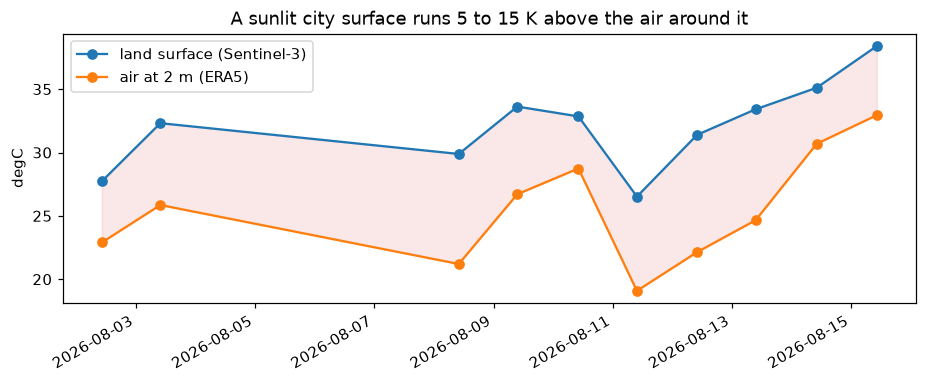

In [15]:
era5_air = "auxiliary_era5_air_temperature_2m"
weather = pd.DataFrame({
    "land surface (Sentinel-3)": cube["lst"].median(["y", "x"]).values,
    "air at 2 m (ERA5)": (cube[era5_air].mean(["y", "x"]) - 273.15).values,
}, index=pd.DatetimeIndex(cube.time.values)).dropna()
fig, ax = plt.subplots(figsize=(10, 3.6))
weather.plot(ax=ax, marker="o")
ax.fill_between(weather.index, weather.iloc[:, 1], weather.iloc[:, 0], color="tab:red", alpha=0.1)
ax.set_ylabel("degC")
ax.set_title("A sunlit city surface runs 5 to 15 K above the air around it")
fig.savefig(FIGURES / "03_air_vs_surface.png", bbox_inches="tight")
plt.show()

### Terrain

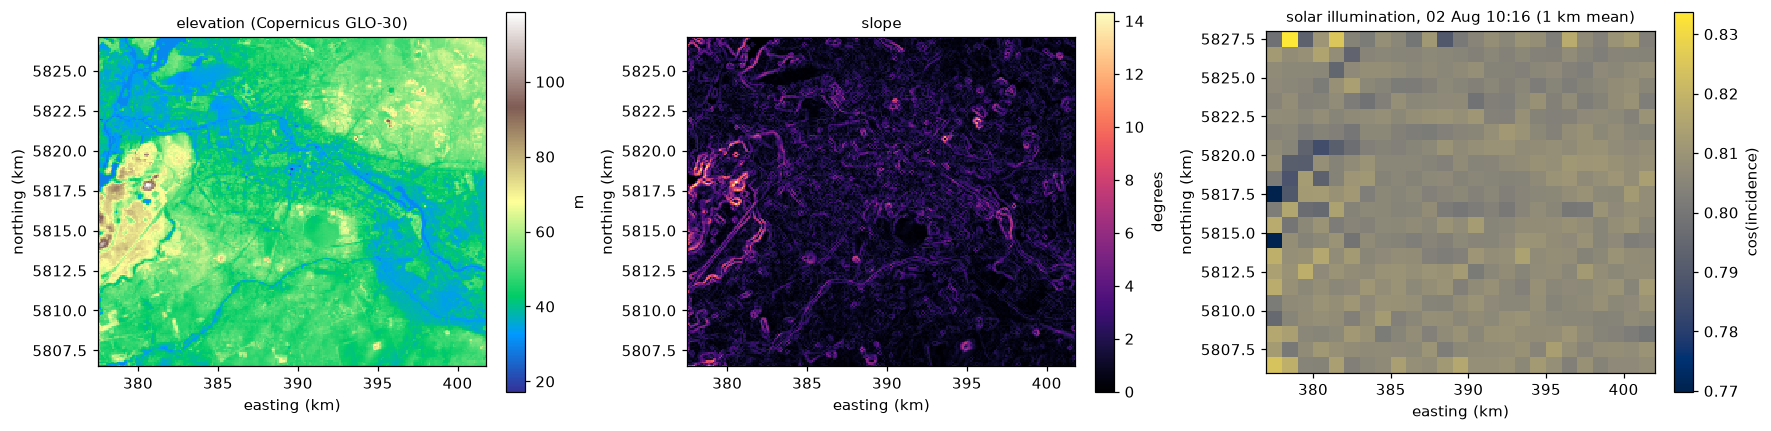

In [16]:
terrain = result.terrain
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
show_map(axes[0], terrain["elevation"], "elevation (Copernicus GLO-30)", cmap="terrain", label="m")
show_map(axes[1], terrain["slope"], "slope", cmap="magma", label="degrees")
show_map(axes[2], cube["cos_incidence"].isel(time=0), f"solar illumination, {pd.Timestamp(cube.time.values[0]):%d %b %H:%M} (1 km mean)", cmap="cividis", label="cos(incidence)")
plt.show()

## 5. How the sources relate to temperature

At 1 km, across all clear cells of all scenes: vegetation and water cool, built-up surfaces warm. These are the relations the downscaling models of notebook 04 learn, one scene at a time.

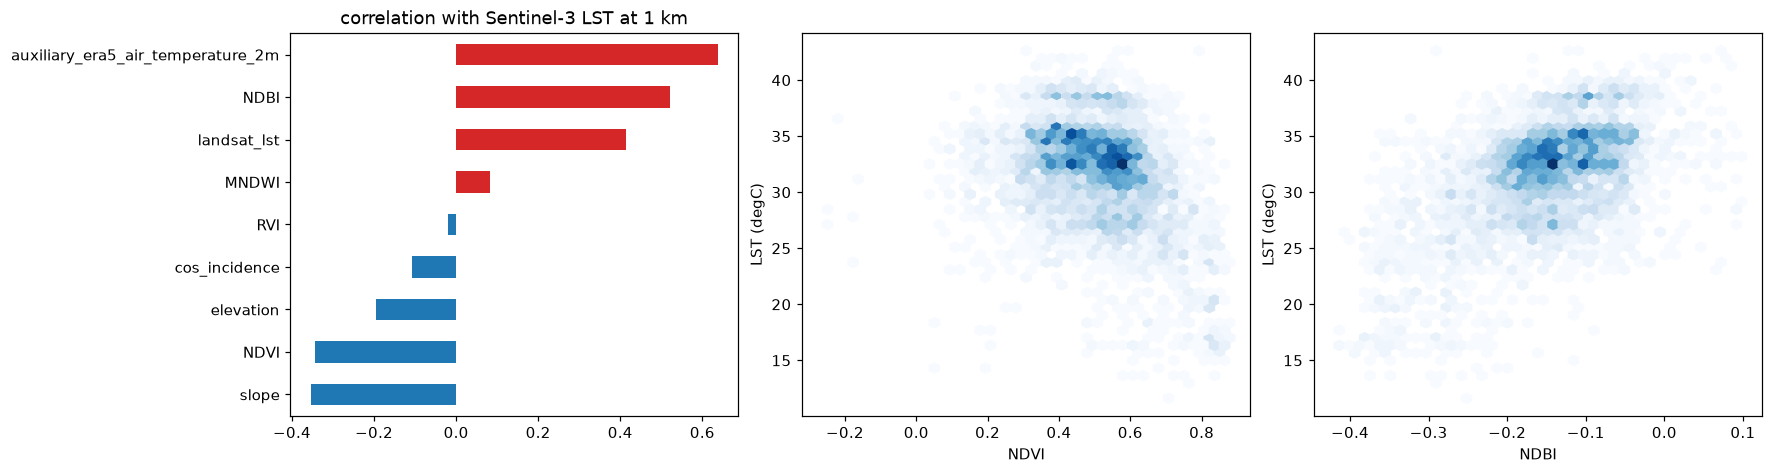

In [17]:
candidates = ["NDVI", "NDBI", "MNDWI", "RVI", "elevation", "slope", "cos_incidence", "landsat_lst", era5_air]
columns = [name for name in candidates if name in cube]
table = cube[["lst", *columns]].to_dataframe()[["lst", *columns]].dropna(subset=["lst"])
correlations = table.corr()["lst"].drop("lst").sort_values()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
correlations.plot.barh(ax=axes[0], color=["tab:blue" if v < 0 else "tab:red" for v in correlations])
axes[0].set_title("correlation with Sentinel-3 LST at 1 km")
for ax, name in zip(axes[1:], ("NDVI", "NDBI")):
    ax.hexbin(table[name], table["lst"], gridsize=40, cmap="Blues", mincnt=1)
    ax.set_xlabel(name)
    ax.set_ylabel("LST (degC)")
fig.savefig(FIGURES / "03_relations.png", bbox_inches="tight")
plt.show()

## 6. Fusion diagnostics and saving

`fusion_quality` records, for each Sentinel-3 scene, the fraction of features that were available. `result.save` writes every cube plus the auxiliary sources, the request and the provenance; notebook 05 animates these.

In [18]:
quality_name = next(name for name in cube.data_vars if "availability" in name or name.startswith("fusion_"))
cube[quality_name].to_series().round(2).rename(quality_name).to_frame().T

time,2026-08-02 10:16:35.048924,2026-08-03 09:50:23.896256,2026-08-04 10:02:53.420753,2026-08-08 09:59:08.810295,2026-08-09 08:54:17.033925,2026-08-09 09:32:57.922360,2026-08-10 10:09:05.372192,2026-08-11 09:42:54.478075,2026-08-12 09:55:24.487459,2026-08-13 09:29:13.567080,2026-08-14 10:05:21.004536,2026-08-15 10:17:50.953440
feature_availability,0.96,0.97,0.93,0.89,0.95,0.99,0.93,0.96,0.81,0.82,0.99,0.95


In [19]:
export = OUT / "03_export"
saved = result.save(export / "result")
pd.DataFrame([{"store": p.relative_to(saved).as_posix(), "MB": round(sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 1e6, 1) if p.is_dir() else round(p.stat().st_size / 1e6, 3)}
              for p in sorted(saved.rglob("*")) if p.suffix in (".zarr", ".json")])

,store,MB
0,auxiliary/cams.zarr,0.100
1,auxiliary/era5.zarr,0.300
2,auxiliary/openaq.zarr,0.000
3,auxiliary/openaq_grid.zarr,3.000
4,cube.zarr,0.400
5,predictor_cube.zarr,19.700
6,predictors/ecostress.zarr,0.500
7,predictors/landsat.zarr,0.400
8,predictors/sentinel1.zarr,8.900
9,predictors/sentinel2.zarr,7.500


## Next

[04 Downscaling](04_downscaling.ipynb) sharpens the Sentinel-3 temperature to 100 m with these predictors.